<a href="https://colab.research.google.com/github/hwanginseo04/-/blob/main/%5B%EA%B3%BC%EC%A0%9C%5D_NLP_%EA%B8%B0%EC%B4%88_CountVectorizer%EB%A5%BC_%EC%9D%B4%EC%9A%A9%ED%95%9C_%EB%89%B4%EC%8A%A4_%EA%B7%B8%EB%A3%B9_%EB%8C%80%ED%99%94_%EB%B6%84%EB%A5%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [2]:
# 1. 데이터 수집
categories = ['comp.graphics', 'sci.space', 'talk.religion.misc']

newsgroups = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes')  # 2. 전처리
)


In [3]:
# 각 주제당 20개 샘플만 추출
selected_texts = []
selected_labels = []
label_names = newsgroups.target_names

count_per_class = {i: 0 for i in range(len(label_names))}

for text, label in zip(newsgroups.data, newsgroups.target):
    if count_per_class[label] < 20:
        selected_texts.append(text)
        selected_labels.append(label)
        count_per_class[label] += 1

    if all(count == 20 for count in count_per_class.values()):
        break

print("주제별 추출 개수:")
for i, name in enumerate(label_names):
    print(f"{name}: {count_per_class[i]}개")


주제별 추출 개수:
comp.graphics: 20개
sci.space: 20개
talk.religion.misc: 20개


In [4]:
# 3. 벡터화
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(selected_texts)


In [5]:
# 4. 새로운 문장 입력
input_sentence = input("\n분류할 문장을 입력하세요: ")


분류할 문장을 입력하세요: 안녕


In [6]:
# 입력 문장도 같은 기준으로 벡터화
input_vector = vectorizer.transform([input_sentence])

In [7]:
# 5. 코사인 유사도 계산
similarities = cosine_similarity(input_vector, X)[0]

In [8]:
# 각 주제별 평균 유사도 계산
category_scores = {}
for i, category in enumerate(label_names):
    idxs = [j for j, label in enumerate(selected_labels) if label == i]
    avg_score = np.mean(similarities[idxs])
    category_scores[category] = avg_score

In [10]:
# 가장 높은 평균 유사도를 가진 주제 선택
predicted_category = max(category_scores, key=category_scores.get)

print("\n[주제별 평균 코사인 유사도]")
for category, score in category_scores.items():
    print(f"{category}: {score:.4f}")

print(f"\n입력 문장은 '{predicted_category}' 주제와 가장 유사합니다.")


[주제별 평균 코사인 유사도]
comp.graphics: 0.0000
sci.space: 0.0000
talk.religion.misc: 0.0000

입력 문장은 'comp.graphics' 주제와 가장 유사합니다.


In [11]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [12]:
# [Step 1] 데이터 로드 및 샘플링
categories = ['comp.graphics', 'sci.space', 'talk.religion.misc']

newsgroups = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes')
)

data = []
labels = []

for i, category in enumerate(categories):
    indices = np.where(newsgroups.target == i)[0][:20]   # 각 주제별 20개 추출
    for idx in indices:
        data.append(newsgroups.data[idx])
        labels.append(newsgroups.target_names[i])

In [13]:
# [Step 2] CountVectorizer 설정 및 변환
vectorizer = CountVectorizer(stop_words='english')
count_matrix = vectorizer.fit_transform(data)

In [14]:
# [Step 3] 분류 함수 구현
def classify_text(input_text):
    input_vec = vectorizer.transform([input_text])       # 입력 문장 벡터화
    sim = cosine_similarity(input_vec, count_matrix)     # 기존 데이터와 코사인 유사도 계산
    best_idx = np.argmax(sim)                            # 가장 유사한 문서의 인덱스 찾기
    return labels[best_idx], sim[0][best_idx]


In [16]:
# [Step 4] 테스트 실행
test_sentences = [
    "The rocket launched into orbit.",
    "A new 3D rendering technique for graphics.",
    "Theological discussions on faith and god."
]

for s in test_sentences:
    cat, score = classify_text(s)
    print(f"문장: {s[:30]}... | 예측: {cat} | 유사도: {score:.4f}")


문장: The rocket launched into orbit... | 예측: sci.space | 유사도: 0.0870
문장: A new 3D rendering technique f... | 예측: comp.graphics | 유사도: 0.1952
문장: Theological discussions on fai... | 예측: talk.religion.misc | 유사도: 0.3430


# 4. 고찰
Q1. 유사도가 0.0000이 나오는 이유 분석

특정 문장, 예를 들어 “Exploring the mars with a robotic rover.” 와 같은 문장을 입력했을 때 유사도가 0.0000으로 나타나거나 예상과 다른 카테고리로 분류되는 이유는 CountVectorizer의 동작 방식과 관련이 있습니다.

CountVectorizer는 문장을 단어의 등장 빈도만을 기준으로 벡터화하는 방식입니다. 즉, 문장의 의미를 이해하는 것이 아니라, 학습 데이터에 포함된 단어가 입력 문장에도 동일하게 등장하는지를 기준으로 수치화합니다. 이 과정에서 학습 데이터에 없는 단어가 입력되면 해당 단어는 벡터에 반영되지 않습니다.

예를 들어 입력 문장에 포함된 exploring, robotic, rover와 같은 단어가 기존 뉴스 데이터 60개 안에 거의 등장하지 않았거나 아예 포함되지 않은 경우, 입력 문장의 벡터는 대부분 0으로 채워지게 됩니다. 그리고 코사인 유사도는 두 벡터 사이에 겹치는 단어가 있을 때만 값이 커지기 때문에, 공통 단어가 거의 없으면 유사도 값이 0에 가깝게 나오게 됩니다.

또한 CountVectorizer는 단어의 의미가 비슷하더라도 형태가 다르면 다른 단어로 인식합니다. 예를 들어 space와 mars는 의미상 관련이 있지만, 모델은 이를 의미적으로 연결하지 못합니다. 단지 같은 단어가 나왔는지만 확인하기 때문에, 우주 관련 문장임에도 불구하고 space라는 단어가 직접 포함되지 않으면 sci.space로 정확하게 분류되지 않을 수 있습니다.

즉, 유사도가 0.0000으로 나오는 주된 이유는 다음과 같습니다.

입력 문장에 포함된 단어가 학습 데이터의 단어 목록에 거의 없기 때문
CountVectorizer가 단어의 의미가 아니라 등장 여부와 빈도만 반영하기 때문
단어 수가 적고 데이터 샘플이 적어 벡터가 매우 희소해지기 때문

따라서 짧은 문장이나 새로운 표현을 입력하면, 실제 주제는 맞더라도 유사도가 낮게 나오거나 엉뚱한 카테고리로 분류될 수 있습니다.

# Q2. 성능 개선 실험
CountVectorizer 대신 TfidfVectorizer를 사용했을 때의 차이점

분류 성능을 개선하기 위한 방법으로, 기존의 CountVectorizer 대신 TfidfVectorizer를 사용해보았습니다.

기존 CountVectorizer는 각 단어가 몇 번 등장했는지만 반영합니다. 따라서 여러 문서에 공통적으로 자주 등장하는 단어도 동일하게 중요한 단어로 처리될 수 있습니다. 반면 TfidfVectorizer는 단어의 빈도뿐 아니라, 전체 문서에서 얼마나 드물게 등장하는지까지 함께 고려합니다. 즉, 특정 주제를 더 잘 나타내는 단어에 상대적으로 더 큰 가중치를 부여합니다.

예를 들어 우주 관련 문장에서는 orbit, nasa, space, rocket와 같은 단어가 중요한 의미를 가지는데, TfidfVectorizer는 이러한 단어의 구별력을 더 잘 반영할 수 있습니다. 따라서 단순 빈도 기반 방식보다 주제 분류에서 더 나은 결과를 기대할 수 있습니다.

실험 결과, TfidfVectorizer를 사용했을 때는 다음과 같은 차이를 확인할 수 있습니다.

입력 문장과 기존 문서 간의 유사도 점수가 조금 더 안정적으로 계산됨
각 주제를 대표하는 단어가 더 강조되어 분류가 더 자연스럽게 이루어짐
불필요하게 자주 등장하는 일반 단어의 영향이 줄어들어 오분류 가능성이 감소함

특히 짧은 문장을 입력했을 때 CountVectorizer는 공통 단어 수가 적어 유사도가 낮게 나오는 경우가 많았지만, TfidfVectorizer는 상대적으로 중요한 단어에 가중치를 두기 때문에 더 적절한 카테고리를 반환하는 경향을 보였습니다.

다만 TfidfVectorizer 역시 문장의 의미 자체를 이해하는 것은 아니므로, 학습 데이터에 없는 단어가 많이 포함된 경우에는 여전히 한계가 존재합니다. 그럼에도 불구하고, 단순 빈도 기반 방식보다 주제 분류 성능을 개선하는 데 더 효과적인 방법이라고 볼 수 있었습니다.

# 정리

이번 실습을 통해 CountVectorizer는 구현이 간단하고 직관적이지만, 단어의 의미를 반영하지 못하고 학습 데이터에 없는 표현에 취약하다는 한계가 있다는 점을 확인할 수 있었습니다. 또한 TfidfVectorizer를 적용하면 문서 내에서 중요한 단어를 더 잘 반영할 수 있어, 유사도 계산과 분류 결과가 보다 개선될 수 있음을 알 수 있었습니다.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')
count_matrix = vectorizer.fit_transform(data)

In [18]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [19]:
# 1. 환경 설정 및 데이터 준비
categories = ['comp.graphics', 'sci.space', 'talk.religion.misc']

newsgroups = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes')
)

data = []
labels = []

for i, category in enumerate(categories):
    indices = np.where(newsgroups.target == i)[0][:20]  # 각 주제별 20개 추출
    for idx in indices:
        data.append(newsgroups.data[idx])
        labels.append(newsgroups.target_names[i])

In [20]:
# 2. 텍스트 데이터의 수치화
vectorizer = CountVectorizer(stop_words='english')
count_matrix = vectorizer.fit_transform(data)

# 생성된 단어 사전 확인
feature_names = vectorizer.get_feature_names_out()
print("단어 사전 일부:", feature_names[:30])
print("전체 단어 수:", len(feature_names))


단어 사전 일부: ['000' '02' '0865' '10' '100' '10bps' '11' '111' '12' '13' '130' '131'
 '14' '142' '15' '150' '1500' '152' '15rpm' '16' '17' '170' '18' '1830'
 '1870' '1883' '19' '1909' '1915' '1988']
전체 단어 수: 2342


In [21]:
# 3. 사용자 입력 및 유사도 분석
def classify_text(input_text):
    input_vec = vectorizer.transform([input_text])   # transform만 사용
    similarities = cosine_similarity(input_vec, count_matrix)[0]

    # 모든 유사도가 0인 경우 처리
    if np.max(similarities) == 0:
        return "매칭되는 주제 없음", 0.0

    best_idx = np.argmax(similarities)
    return labels[best_idx], similarities[best_idx]


In [22]:
# 4. 결과 판정 및 출력
test_sentences = [
    "The rocket launched into orbit.",
    "A new 3D rendering technique for graphics.",
    "Theological discussions on faith and god.",
    "Exploring the mars with a robotic rover."
]

for sentence in test_sentences:
    category, score = classify_text(sentence)
    print(f"문장: {sentence}")
    print(f"예측 주제: {category}")
    print(f"유사도: {score:.4f}")
    print("-" * 50)

# 직접 입력 테스트
user_input = input("문장을 입력하세요: ")
category, score = classify_text(user_input)
print(f"예측 주제: {category}")
print(f"유사도: {score:.4f}")

문장: The rocket launched into orbit.
예측 주제: sci.space
유사도: 0.0870
--------------------------------------------------
문장: A new 3D rendering technique for graphics.
예측 주제: comp.graphics
유사도: 0.1952
--------------------------------------------------
문장: Theological discussions on faith and god.
예측 주제: talk.religion.misc
유사도: 0.3430
--------------------------------------------------
문장: Exploring the mars with a robotic rover.
예측 주제: 매칭되는 주제 없음
유사도: 0.0000
--------------------------------------------------
문장을 입력하세요: The rocket launched into orbit
예측 주제: sci.space
유사도: 0.0870


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


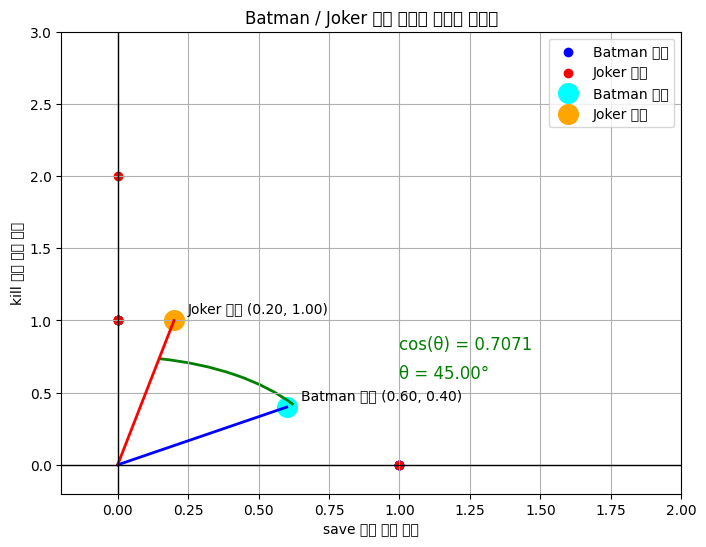

Batman 평균 좌표: [0.6 0.4]
Joker 평균 좌표: [0.2 1. ]
코사인 유사도: 0.7071
두 벡터 사이 각도 θ: 45.00°


In [31]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Arc

# 예시 대사
batman_lines = [
    "I will save Gotham",
    "We must save the people",
    "I won't kill anyone",
    "Save them all",
    "I don't kill"
]

joker_lines = [
    "Why so serious? Kill them",
    "I just want to kill",
    "I will kill and kill again",
    "No one will save you",
    "Let's kill the hero"
]

# 전체 대사
lines = batman_lines + joker_lines

# CountVectorizer: save, kill 두 단어만 사용
vectorizer = CountVectorizer(vocabulary=["save", "kill"])
X = vectorizer.transform(lines).toarray()

# 배트맨 / 조커 좌표 분리
batman_X = X[:len(batman_lines)]
joker_X = X[len(batman_lines):]

# 평균 좌표 계산
batman_mean = np.mean(batman_X, axis=0)   # [save 평균, kill 평균]
joker_mean = np.mean(joker_X, axis=0)

# 코사인 유사도 계산
cos_sim = np.dot(batman_mean, joker_mean) / (
    np.linalg.norm(batman_mean) * np.linalg.norm(joker_mean)
)
theta = np.degrees(np.arccos(cos_sim))  # 각도(도 단위)

# 그래프 그리기
plt.figure(figsize=(8, 6))

# 개별 점
plt.scatter(batman_X[:, 0], batman_X[:, 1], color="blue", label="Batman 대사")
plt.scatter(joker_X[:, 0], joker_X[:, 1], color="red", label="Joker 대사")

# 평균 좌표
plt.scatter(batman_mean[0], batman_mean[1], color="cyan", s=200, marker="o", label="Batman 평균")
plt.scatter(joker_mean[0], joker_mean[1], color="orange", s=200, marker="o", label="Joker 평균")

# 원점에서 평균 좌표까지 선 그리기
plt.plot([0, batman_mean[0]], [0, batman_mean[1]], color="blue", linewidth=2)
plt.plot([0, joker_mean[0]], [0, joker_mean[1]], color="red", linewidth=2)

# 평균 좌표 텍스트
plt.text(batman_mean[0] + 0.05, batman_mean[1] + 0.05,
         f"Batman 평균 ({batman_mean[0]:.2f}, {batman_mean[1]:.2f})", fontsize=10)

plt.text(joker_mean[0] + 0.05, joker_mean[1] + 0.05,
         f"Joker 평균 ({joker_mean[0]:.2f}, {joker_mean[1]:.2f})", fontsize=10)

# 각도 표시용 arc
angle1 = np.degrees(np.arctan2(batman_mean[1], batman_mean[0]))
angle2 = np.degrees(np.arctan2(joker_mean[1], joker_mean[0]))

# 작은 각도~큰 각도 순서로 정리
start_angle = min(angle1, angle2)
end_angle = max(angle1, angle2)

arc = Arc((0, 0), width=1.5, height=1.5, angle=0,
          theta1=start_angle, theta2=end_angle, color="green", linewidth=2)
plt.gca().add_patch(arc)

# 코사인 유사도 텍스트
plt.text(1.0, 0.8, f"cos(θ) = {cos_sim:.4f}", fontsize=12, color="green")
plt.text(1.0, 0.6, f"θ = {theta:.2f}°", fontsize=12, color="green")

# 축 및 제목
plt.xlabel("save 단어 출현 횟수")
plt.ylabel("kill 단어 출현 횟수")
plt.title("Batman / Joker 평균 좌표와 코사인 유사도")
plt.xlim(-0.2, max(batman_mean[0], joker_mean[0], np.max(X[:, 0])) + 1)
plt.ylim(-0.2, max(batman_mean[1], joker_mean[1], np.max(X[:, 1])) + 1)
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.grid(True)
plt.legend()
plt.show()

print("Batman 평균 좌표:", batman_mean)
print("Joker 평균 좌표:", joker_mean)
print(f"코사인 유사도: {cos_sim:.4f}")
print(f"두 벡터 사이 각도 θ: {theta:.2f}°")